# 02 — Factor Construction, Step by Step

This notebook rebuilds the suite's two daily AI exposure factors **interactively, using the
project's own pipeline code** (`src.pipelines.construct_factors.FactorConstructor`), so that
every number shown here is exactly what the production pipeline produces — the documentation
cannot drift from the implementation.

The two factors (see `part_1_ai_exposure_factor_suite_etf_factors.md` for the full spec):

1. **AI Theme Factor ($F_{AITheme}$)** — lagged-AUM-weighted basket of AI-theme ETF excess returns.
2. **AI Infrastructure Factor ($F_{AIInfra}$)** — semiconductor ETF (SOXX) excess return.

**Ground rules for this notebook**

- Fully **offline**: it reads only the already-fetched files under `data/` and `config/`.
  No yfinance, FRED, or any other network call.
- Executed top-to-bottom with CWD set to the project root, so relative paths like `data/...` resolve.
- Sections: (0) setup → (1) inputs → (2) risk-free rate → (3) AI Theme factor →
  (4) AI Infra factor → (5) full end-to-end construction → (6) validation → (7) takeaways.

## 0. Setup

One import/setup cell. Two things worth noting:

- **Paths.** `nbconvert` executes a notebook with CWD = the notebook's own directory
  (`notebooks/`). We anchor everything at the project root with `pathlib` and `os.chdir`,
  so `data/...` paths work identically in interactive and executed runs.
- **Warning filter.** `pandas.read_feather` currently routes through
  `pyarrow.feather.read_feather`, which pyarrow ≥ 24 deprecates with a noisy `FutureWarning`.
  The warning is harmless (Feather V2 *is* the Arrow IPC format); we silence it so cell
  outputs stay readable.

In [1]:
from pathlib import Path
import os
import warnings

# Anchor all paths at the project root (nbconvert runs with CWD = notebooks/).
PROJECT_ROOT = Path("..").resolve()
os.chdir(PROJECT_ROOT)

# Silence the pyarrow/pandas FutureWarning emitted by pd.read_feather (see markdown above).
warnings.filterwarnings("ignore", category=FutureWarning, message=".*read_feather.*")

import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.pipelines.construct_factors import FactorConstructor
from src.utils.config import get_config
from src.utils.validation import validate_weights

# Surface the pipeline's own log messages — they document what each call does.
logging.basicConfig(level=logging.INFO, format="%(levelname)s [%(name)s]: %(message)s")

pd.set_option("display.float_format", lambda v: f"{v:,.6f}")
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

config = get_config()
constructor = FactorConstructor(config)

print(f"Project root:            {PROJECT_ROOT}")
print(f"Primary semi ETF:        {constructor.primary_semi_etf}")
print(f"Alternative semi ETF:    {constructor.alternative_semi_etf}")
print(f"max_single_etf_weight:   {config.max_single_etf_weight} (None = no cap)")

INFO [src.pipelines.construct_factors]: Using SOXX as primary semiconductor ETF


INFO [src.pipelines.construct_factors]: Loaded 15 ETF classifications


Project root:            /home/fire/Documents/AI-Factor
Primary semi ETF:        SOXX
Alternative semi ETF:    SMH
max_single_etf_weight:   None (None = no cap)


## 1. Inputs

Three raw inputs feed factor construction:

| File | Content | Key columns |
|---|---|---|
| `data/raw/etf_returns/etf_returns.feather` | Daily OHLCV + simple daily returns (from adjusted prices) for the 15 candidate ETFs | `date` (tz-aware — the pipeline normalizes it), `ticker`, `return`, `data_quality_flag` |
| `data/raw/etf_aum/etf_aum_current.feather` | **Current snapshot** of assets under management — one row per ETF | `ticker`, `aum` (USD), `as_of_date` |
| `data/reference/rf_rate_TB3MS.feather` | Monthly 3-month T-bill rate (FRED TB3MS), **annualized, decimal** (0.036 = 3.6% p.a.) | `date`, `rf_rate` |

The ETF **universe** comes from `config/etf_classifications.csv`: 7 theme ETFs, 2 infra
(semiconductor) ETFs, and 6 explicitly excluded funds (leveraged products, broad tech,
and AI-*selected* funds that are not AI *exposure*).

In [2]:
etf_returns = pd.read_feather(PROJECT_ROOT / "data/raw/etf_returns/etf_returns.feather")
etf_aum = pd.read_feather(PROJECT_ROOT / "data/raw/etf_aum/etf_aum_current.feather")
rf_rate = pd.read_feather(PROJECT_ROOT / "data/reference/rf_rate_TB3MS.feather")

print(f"etf_returns: {etf_returns.shape[0]:,} rows x {etf_returns.shape[1]} cols, "
      f"{etf_returns['ticker'].nunique()} tickers")
print(f"etf_aum:     {etf_aum.shape[0]} rows (current snapshot only)")
print(f"rf_rate:     {rf_rate.shape[0]:,} monthly obs, "
      f"{rf_rate['date'].min():%Y-%m} -> {rf_rate['date'].max():%Y-%m}")

etf_returns.head(3)

etf_returns: 23,569 rows x 9 cols, 9 tickers
etf_aum:     9 rows (current snapshot only)
rf_rate:     1,109 monthly obs, 1934-01 -> 2026-05


,date,ticker,open,high,low,close,volume,return,data_quality_flag
0,2016-09-13 00:00:00-04:00,BOTZ,14.171088,14.171088,14.171088,14.171088,300,NaN,ok
1,2016-09-14 00:00:00-04:00,BOTZ,14.171088,14.171088,14.171088,14.171088,0,0.000000,ok
2,2016-09-15 00:00:00-04:00,BOTZ,14.171088,14.171088,14.171088,14.171088,0,0.000000,ok


In [3]:
# The ETF universe, straight from config — this is what the constructor reads internally.
cls = constructor.classifications
cols = ["ticker", "fund_name", "bucket", "inception_date", "first_return_date"]
for bucket in ["theme", "infra", "excluded"]:
    sub = cls[cls["bucket"] == bucket][cols]
    print(f"\n=== bucket = {bucket} ({len(sub)} ETFs) ===")
    print(sub.to_string(index=False))


=== bucket = theme (7 ETFs) ===
ticker                                          fund_name bucket inception_date first_return_date
  BOTZ                         Global X Robotics & AI ETF  theme     2016-09-12        2016-09-15
  IRBO               iShares Robotics and Multifactor ETF  theme     2018-06-26        2018-06-27
  ROBO      ROBO Global Robotics and Automation Index ETF  theme     2013-10-22        2013-10-23
   AIQ  Global X Artificial Intelligence & Technology ETF  theme     2018-05-10        2018-05-11
  THNQ ROBO Global Artificial Intelligence Technology ETF  theme     2018-04-05        2018-04-06
  WTAI            WisdomTree Artificial Intelligence Fund  theme     2018-04-05        2018-04-06
  ARKQ           ARK Autonomous Technology & Robotics ETF  theme     2014-09-03        2014-09-04

=== bucket = infra (2 ETFs) ===
ticker                 fund_name bucket inception_date first_return_date
  SOXX iShares Semiconductor ETF  infra     2001-07-10        2001-07-11
   S

In [4]:
# Current AUM snapshot (USD) for the ETFs that have one — note as_of_date is a single day.
aum_view = etf_aum[["ticker", "aum", "as_of_date"]].copy()
aum_view["aum_usd_bn"] = aum_view["aum"] / 1e9
print(aum_view.to_string(index=False))
print()
print(Path("config/semicond_etf_choice.txt").read_text())

ticker         aum as_of_date  aum_usd_bn
  BOTZ  3743227648 2026-06-20    3.743228
  IRBO   788096064 2026-06-20    0.788096
  ROBO  2022659456 2026-06-20    2.022659
   AIQ 10853201920 2026-06-20   10.853202
  THNQ   432977952 2026-06-20    0.432978
  WTAI   622808320 2026-06-20    0.622808
  SOXX 38373490688 2026-06-20   38.373491
   SMH 67822489600 2026-06-20   67.822490
  ARKQ  2405846528 2026-06-20    2.405847

# Semiconductor ETF Selection for AI Infrastructure Factor
# This file specifies which semiconductor ETF to use as the AI Infra proxy

# Primary Selection
PRIMARY: SOXX

# Reasoning for SOXX selection:
# 1. Long history (inception 2001) - provides long return series
# 2. High liquidity - largest semiconductor ETF by AUM
# 3. Broad coverage - 30 largest US semiconductor companies
# 4. Market-cap weighted - standard approach
# 5. Reliable total return data available

# Alternative for Robustness Testing
ALTERNATIVE: SMH

# Notes on SMH vs SOXX:
# - SMH: 25 holdings, more con

## 2. Risk-Free Rate Preparation

Excess returns need a *daily* risk-free rate, but TB3MS arrives **monthly** and
**annualized**. The constructor does two transformations (identical in both factor builders):

1. **Forward-fill to daily.** A daily calendar is built starting 45 days *before* the
   factor's first return date (so the 1st-of-month TB3MS anchor always precedes the window
   and no leading rf NaNs can occur), the monthly observations are merged onto it, and each
   month's rate is carried forward (`ffill`) until the next monthly print. The merged output
   coalesces the rf series from both factor legs, so the stored `rf_rate` column has no NaN
   anywhere.

2. **Annual → daily conversion** via `FactorConstructor._annual_rf_to_daily`:

$$ r^{daily}_{f,t} = \frac{r^{annual}_{f,t}}{252} $$

The simple `/252` convention matches the $\sqrt{252}$ annualization used in the diagnostics.
The `rf_rate` column stored in the final output is this **daily** rate, not the annualized one.

> **Methodology note (documented bug, now fixed).** An earlier version of the pipeline
> subtracted the *annualized* rate from *daily* returns — i.e. ~3.6% per **day** in a
> 3.6% rate environment — producing a mean daily "excess" return of −1.79%/day and
> corrupting every excess return. The `/252` conversion above is the fix; keep it in mind
> whenever reading historical revisions of the factor file.

In [5]:
# Monthly TB3MS, annualized decimal — tail of the series is what matters for the factor window.
print(rf_rate.tail(6).to_string(index=False))

# Reproduce the constructor's rf preparation step by step on the theme sample window.
# The window starts 45 days before the first return date so the 1st-of-month TB3MS anchor
# is always inside the window (this is what eliminated the old leading-NaN artifact).
from datetime import date, timedelta

rf = rf_rate.copy()
rf["date"] = pd.to_datetime(rf["date"], utc=True).dt.tz_localize(None).dt.normalize()

max_date = pd.to_datetime(etf_returns["date"], utc=True).dt.tz_localize(None).dt.normalize().max()
start_date = str(date(2013, 10, 22) - timedelta(days=45))  # 45 days before theme window start
dates = pd.date_range(start_date, max_date, freq="D")
rf_daily = pd.DataFrame({"date": dates}).merge(rf, on="date", how="left")
rf_daily["rf_annual_ffill"] = rf_daily["rf_rate"].ffill()
rf_daily["rf_daily"] = FactorConstructor._annual_rf_to_daily(rf_daily["rf_annual_ffill"])

print("\nForward-filled + converted, around a month boundary:")
print(rf_daily[rf_daily["date"].between("2026-04-28", "2026-05-04")].to_string(index=False))

last = rf_daily.dropna().iloc[-1]
print(f"\nLatest: annualized {last['rf_annual_ffill']:.4f} -> daily {last['rf_daily']:.8f} "
      f"({last['rf_annual_ffill']:.2%} p.a. / 252)")

      date  rf_rate
2025-12-01 0.035900
2026-01-01 0.035700
2026-02-01 0.036000
2026-03-01 0.036100
2026-04-01 0.036100
2026-05-01 0.036000

Forward-filled + converted, around a month boundary:
      date  rf_rate  rf_annual_ffill  rf_daily
2026-04-28      NaN         0.036100  0.000143
2026-04-29      NaN         0.036100  0.000143
2026-04-30      NaN         0.036100  0.000143
2026-05-01 0.036000         0.036000  0.000143
2026-05-02      NaN         0.036000  0.000143
2026-05-03      NaN         0.036000  0.000143
2026-05-04      NaN         0.036000  0.000143

Latest: annualized 0.0360 -> daily 0.00014286 (3.60% p.a. / 252)


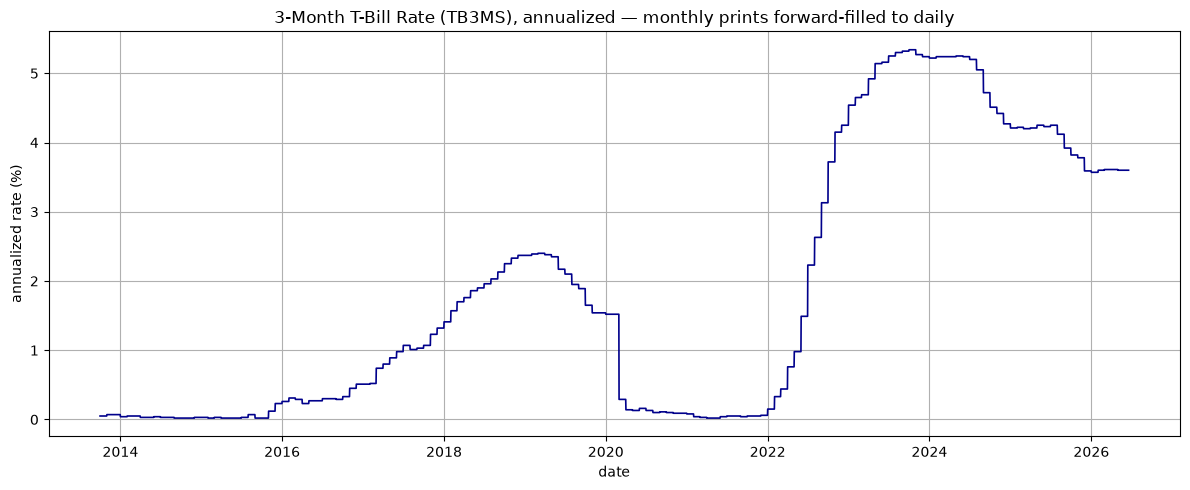

In [6]:
fig, ax = plt.subplots()
recent = rf_daily[rf_daily["date"] >= "2010-01-01"]
ax.plot(recent["date"], recent["rf_annual_ffill"] * 100, lw=1.2, color="darkblue")
ax.set_title("3-Month T-Bill Rate (TB3MS), annualized — monthly prints forward-filled to daily")
ax.set_ylabel("annualized rate (%)")
ax.set_xlabel("date")
plt.tight_layout()
plt.show()

## 3. AI Theme Factor

`constructor.construct_ai_theme_factor(etf_returns, etf_aum, rf_rate)` implements the spec:

$$ F_{AITheme,t} = \sum_{e \in Active_t} w_{e,t-1} \cdot \left( R_{e,t} - r^{daily}_{f,t} \right) $$

Internal steps, in order:

1. **Universe filter** — keep the 7 ETFs with `bucket == "theme"` in the classifications file.
2. **Date normalization** — tz-aware timestamps are converted to tz-naive midnight dates.
3. **Excess returns per ETF** — merge the daily rf series and compute $R_{e,t} - r_{f,t}$.
4. **Lagged AUM weights** — each ETF's AUM is lagged by one observation so weights are
   known before returns realize:

$$ w_{e,t-1} = \frac{AUM_{e,t-1}}{\sum_{j \in Active_{t-1}} AUM_{j,t-1}} $$

5. **Renormalization across active ETFs** — the denominator sums only over ETFs *with return
   data on day $t$*, so weights always sum to 1 over the currently tradable basket. This is
   what makes **ETF inclusion point-in-time**: an ETF enters the basket on its first actual
   return date (ROBO: 2013-10-23) and there is no pre-inception data to contaminate the factor.
6. **Aggregation** — the weighted excess return sum above.
7. **Daily diagnostics** — active ETF count $N_t$, largest weight
   $\max_e w_{e,t}$, and the Herfindahl–Hirschman concentration index
   $HHI_t = \sum_e w_{e,t}^2$ (1.0 = single ETF; $1/N$ = equal weights).

> **Known limitation (documented, Phase 2).** Only a **current AUM snapshot** is available —
> there is no historical point-in-time AUM series. The lagged weights therefore use *today's*
> AUM across the whole history, making each ETF's weight **static** over its active period.
> Relative weights will drift from what true historical AUM would imply (e.g. AIQ's large
> inflows post-2022 are projected backwards). *Inclusion*, however, **is** point-in-time via
> return availability. Replacing the snapshot with historical AUM is a planned Phase 2 fix.

In [7]:
# Pass copies: the constructor normalizes the date column of its inputs in place.
ai_theme = constructor.construct_ai_theme_factor(etf_returns.copy(), etf_aum.copy(), rf_rate.copy())

print(f"\nAI Theme factor: {len(ai_theme):,} daily rows")
th = ai_theme["ai_theme_excess_return"].dropna()
print(f"  non-NaN obs:        {len(th):,} "
      f"({ai_theme.loc[th.index, 'date'].min():%Y-%m-%d} -> {ai_theme.loc[th.index, 'date'].max():%Y-%m-%d})")
print(f"  annualized mean:    {th.mean() * 252:.3%}")
print(f"  annualized vol:     {th.std() * np.sqrt(252):.3%}")
print(f"  annualized Sharpe:  {th.mean() / th.std() * np.sqrt(252):.2f}")
ai_theme.head(3)

INFO [src.pipelines.construct_factors]: Constructing AI Theme Factor


INFO [src.pipelines.construct_factors]: Using 7 theme ETFs: ['BOTZ', 'IRBO', 'ROBO', 'AIQ', 'THNQ', 'WTAI', 'ARKQ']


INFO [src.pipelines.construct_factors]: Constructed AI Theme Factor: 3183 days



AI Theme factor: 3,183 daily rows
  non-NaN obs:        3,182 (2013-10-23 -> 2026-06-18)
  annualized mean:    15.197%
  annualized vol:     22.659%
  annualized Sharpe:  0.67


,date,ai_theme_excess_return,ai_theme_basket_return,active_theme_etf_count,largest_theme_etf_weight,theme_etf_hhi,rf_rate,data_quality_flag
0,2013-10-22,NaN,NaN,1.000000,1.000000,1.000000,0.000002,ok
1,2013-10-23,-0.014220,-0.014218,1.000000,1.000000,1.000000,0.000002,ok
2,2013-10-24,0.007210,0.007212,1.000000,1.000000,1.000000,0.000002,ok


Weight per theme ETF (constant over each ETF's active period):
  AIQ    52.01%   active since 2018-05-16
  BOTZ   17.94%   active since 2016-09-13
  ARKQ   11.53%   active since 2014-09-30
  ROBO    9.69%   active since 2013-10-22
  IRBO    3.78%   active since 2018-06-26
  WTAI    2.98%   active since 2021-12-09
  THNQ    2.07%   active since 2020-05-18


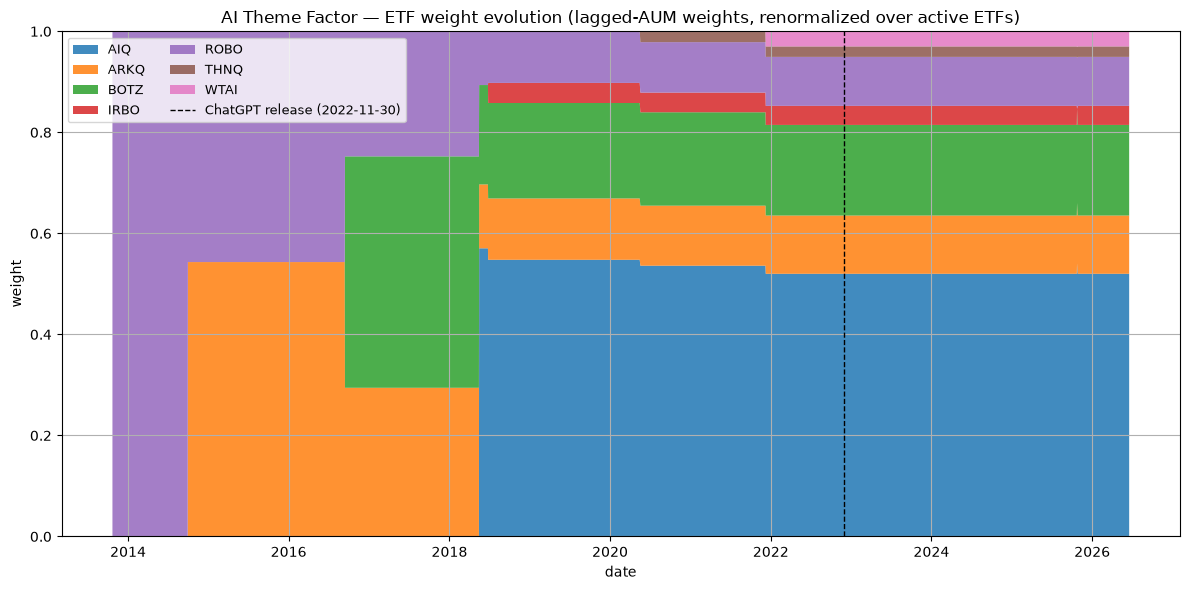

In [8]:
# Daily weights saved by the pipeline for transparency.
weights = pd.read_feather(PROJECT_ROOT / "data/factors/ai_theme_weights.feather")
w = weights.pivot(index="date", columns="ticker", values="weight").fillna(0.0)

# Weights are static within each ETF's active period (current-AUM limitation): show the
# full-history level per ticker and the entry date of each fund.
latest = w.iloc[-1].sort_values(ascending=False)
print("Weight per theme ETF (constant over each ETF's active period):")
for tkr in latest.index:
    first = w.index[w[tkr] > 0].min()
    print(f"  {tkr:5s} {latest[tkr]:7.2%}   active since {first:%Y-%m-%d}")

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(w.index, w.T.values, labels=w.columns, alpha=0.85)
ax.axvline(pd.Timestamp("2022-11-30"), color="black", ls="--", lw=1, label="ChatGPT release (2022-11-30)")
ax.set_title("AI Theme Factor — ETF weight evolution (lagged-AUM weights, renormalized over active ETFs)")
ax.set_ylabel("weight")
ax.set_xlabel("date")
ax.set_ylim(0, 1)
ax.legend(loc="upper left", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

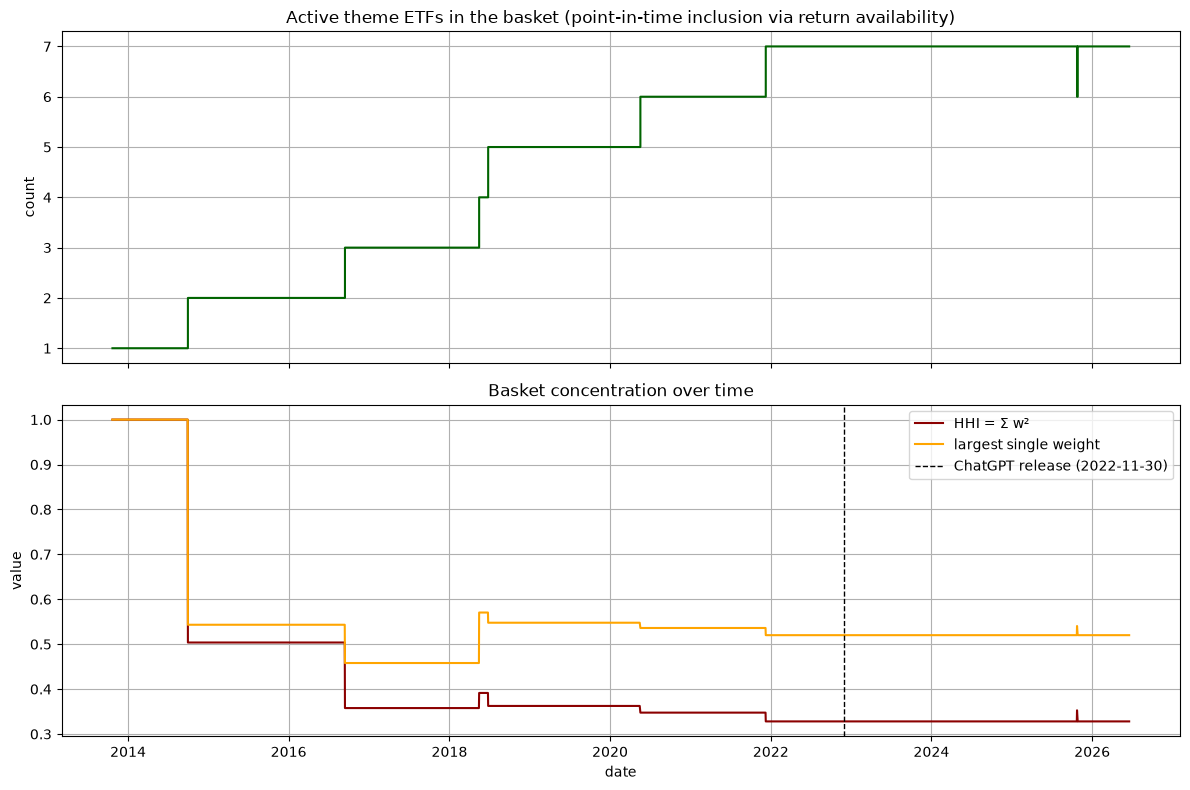

HHI range: 0.328 (1 ETF) -> 1.000; latest HHI = 0.328 with 7 active ETFs


In [9]:
# Concentration diagnostics: active count, largest weight, HHI.
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].step(ai_theme["date"], ai_theme["active_theme_etf_count"], where="post", color="darkgreen")
axes[0].set_title("Active theme ETFs in the basket (point-in-time inclusion via return availability)")
axes[0].set_ylabel("count")
axes[0].set_yticks(range(1, 8))

axes[1].plot(ai_theme["date"], ai_theme["theme_etf_hhi"], color="darkred", label="HHI = Σ w²")
axes[1].plot(ai_theme["date"], ai_theme["largest_theme_etf_weight"], color="orange",
             label="largest single weight")
axes[1].axvline(pd.Timestamp("2022-11-30"), color="black", ls="--", lw=1,
                label="ChatGPT release (2022-11-30)")
axes[1].set_title("Basket concentration over time")
axes[1].set_ylabel("value")
axes[1].set_xlabel("date")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"HHI range: {ai_theme['theme_etf_hhi'].min():.3f} (1 ETF) -> "
      f"{ai_theme['theme_etf_hhi'].max():.3f}; latest HHI = {ai_theme['theme_etf_hhi'].iloc[-1]:.3f} "
      f"with {int(ai_theme['active_theme_etf_count'].iloc[-1])} active ETFs")

## 4. AI Infrastructure Factor

$$ F_{AIInfra,t} = R_{SemiETF,t} - r^{daily}_{f,t} $$

A deliberately **single-ETF** design: the AI infrastructure leg is proxied by one dedicated
semiconductor ETF rather than a basket. The selection is **pre-specified** in
`config/semicond_etf_choice.txt` (not optimized ex-post), with documented criteria:

- **PRIMARY: SOXX** — inception 2001 (longest history), largest semiconductor ETF by AUM,
  30 largest US semiconductor companies, market-cap weighted, reliable total-return data.
- **ALTERNATIVE: SMH** — 25 holdings, more concentrated; reserved for robustness checks
  (`use_alternative=True`) to test whether results hinge on the single-ETF choice.
- Leveraged/inverse products (SOXL, SOXS) are excluded per spec.

Semiconductors are the canonical "picks and shovels" of the AI build-out, so the infra factor
captures the hardware/capex side of AI exposure, complementing the application-layer theme basket.

In [10]:
ai_infra = constructor.construct_ai_infra_factor(etf_returns.copy(), rf_rate.copy())

print(f"\nAI Infra factor ({constructor.primary_semi_etf}): {len(ai_infra):,} daily rows")
inf = ai_infra["ai_infra_excess_return"].dropna()
print(f"  non-NaN obs:        {len(inf):,} "
      f"({ai_infra.loc[inf.index, 'date'].min():%Y-%m-%d} -> {ai_infra.loc[inf.index, 'date'].max():%Y-%m-%d})")
print(f"  annualized mean:    {inf.mean() * 252:.3%}")
print(f"  annualized vol:     {inf.std() * np.sqrt(252):.3%}")
print(f"  annualized Sharpe:  {inf.mean() / inf.std() * np.sqrt(252):.2f}")
ai_infra.head(3)

INFO [src.pipelines.construct_factors]: Constructing AI Infra Factor using SOXX


INFO [src.pipelines.construct_factors]: Constructed AI Infra Factor: 4140 days



AI Infra factor (SOXX): 4,140 daily rows
  non-NaN obs:        4,139 (2010-01-05 -> 2026-06-18)
  annualized mean:    26.437%
  annualized vol:     30.352%
  annualized Sharpe:  0.87


,date,ai_infra_excess_return,ai_infra_etf_return,rf_rate,data_quality_flag,semi_etf_used
0,2010-01-04,NaN,NaN,0.000002,ok,SOXX
1,2010-01-05,-0.001608,-0.001605,0.000002,ok,SOXX
2,2010-01-06,-0.003017,-0.003015,0.000002,ok,SOXX


## 5. Full End-to-End Construction

`constructor.construct_factors()` runs both builders, outer-merges them on `date`, sorts, and
**writes the production output** `data/factors/ai_factor_daily.feather` (plus
`data/factors/ai_theme_weights.feather` for transparency). The write is idempotent: same code
+ same inputs reproduce the shipped file byte-for-byte in content (verified in §6).

Because the merge is an **outer** join, the infra rows extend back to 2010-01-05 while the
theme factor only starts 2013-10-23 — the pre-2013 theme columns are NaN by design (see §6
for the exact NaN pattern).

In [11]:
factors = constructor.construct_factors()

print(f"\nMerged factor table: {factors.shape[0]:,} rows, "
      f"{factors['date'].min():%Y-%m-%d} -> {factors['date'].max():%Y-%m-%d}")
print("\n--- head (pre-theme era: only infra is defined) ---")
display(factors.head(3))
print("--- tail ---")
display(factors.tail(3))

INFO [src.pipelines.construct_factors]: Constructing AI factors...


INFO [src.pipelines.construct_factors]: Constructing AI Theme Factor


INFO [src.pipelines.construct_factors]: Using 7 theme ETFs: ['BOTZ', 'IRBO', 'ROBO', 'AIQ', 'THNQ', 'WTAI', 'ARKQ']


INFO [src.pipelines.construct_factors]: Constructed AI Theme Factor: 3183 days


INFO [src.pipelines.construct_factors]: Constructing AI Infra Factor using SOXX


...

/home/fire/Documents/AI-Factor/.venv/lib/python3.13/site-packages/pandas/io/feather_format.py:65: FutureWarning: pyarrow.feather.write_feather is deprecated as of 24.0.0. Use pyarrow.ipc.new_file() / RecordBatchFileWriter instead. Feather V2 is the Arrow IPC file format.
  feather.write_feather(df, handles.handle, **kwargs)
/home/fire/Documents/AI-Factor/.venv/lib/python3.13/site-packages/pandas/io/feather_format.py:65: FutureWarning: pyarrow.feather.write_feather is deprecated as of 24.0.0. Use pyarrow.ipc.new_file() / RecordBatchFileWriter instead. Feather V2 is the Arrow IPC file format.
  feather.write_feather(df, handles.handle, **kwargs)
INFO [src.pipelines.construct_factors]: Saved 4140 days of AI factors



Merged factor table: 4,140 rows, 2010-01-04 -> 2026-06-18

--- head (pre-theme era: only infra is defined) ---


,date,ai_theme_excess_return,ai_theme_basket_return,active_theme_etf_count,largest_theme_etf_weight,theme_etf_hhi,rf_rate,data_quality_flag,ai_infra_excess_return,ai_infra_etf_return
0,2010-01-04,NaN,NaN,NaN,NaN,NaN,0.000002,NaN,NaN,NaN
1,2010-01-05,NaN,NaN,NaN,NaN,NaN,0.000002,NaN,-0.001608,-0.001605
2,2010-01-06,NaN,NaN,NaN,NaN,NaN,0.000002,NaN,-0.003017,-0.003015


--- tail ---


,date,ai_theme_excess_return,ai_theme_basket_return,active_theme_etf_count,largest_theme_etf_weight,theme_etf_hhi,rf_rate,data_quality_flag,ai_infra_excess_return,ai_infra_etf_return
4137,2026-06-16,-0.022754,-0.022611,7.000000,0.520068,0.328076,0.000143,ok,-0.059352,-0.059209
4138,2026-06-17,-0.004713,-0.004570,7.000000,0.520068,0.328076,0.000143,ok,0.014217,0.014360
4139,2026-06-18,0.027557,0.027699,7.000000,0.520068,0.328076,0.000143,ok,0.066087,0.066230


In [12]:
# Column documentation for data/factors/ai_factor_daily.feather
column_docs = pd.DataFrame([
    ("date", "Trading day (tz-naive, normalized to midnight)."),
    ("ai_theme_excess_return", "F_AITheme: lagged-AUM-weighted theme-ETF excess return. "
                               "NaN before the first theme ETF's first return (ROBO, 2013-10-23)."),
    ("ai_theme_basket_return", "Gross (non-excess) weighted theme basket return, same weights."),
    ("active_theme_etf_count", "Number of theme ETFs with return data that day (1..7)."),
    ("largest_theme_etf_weight", "max weight in the theme basket that day."),
    ("theme_etf_hhi", "Herfindahl index of theme weights: sum(w^2). 1.0 = single ETF, 1/N = equal."),
    ("rf_rate", "DAILY risk-free rate used (annualized TB3MS / 252, forward-filled)."),
    ("data_quality_flag", "'ok' when constructed without detected issues."),
    ("ai_infra_excess_return", "F_AIInfra: SOXX excess return. Defined from 2010-01-05."),
    ("ai_infra_etf_return", "Gross SOXX daily simple return (from adjusted prices)."),
], columns=["column", "description"])
column_docs

,column,description
0,date,"Trading day (tz-naive, normalized to midnight)."
1,ai_theme_excess_return,F_AITheme: lagged-AUM-weighted theme-ETF exces...
2,ai_theme_basket_return,Gross (non-excess) weighted theme basket retur...
3,active_theme_etf_count,Number of theme ETFs with return data that day...
4,largest_theme_etf_weight,max weight in the theme basket that day.
5,theme_etf_hhi,Herfindahl index of theme weights: sum(w^2). 1...
6,rf_rate,DAILY risk-free rate used (annualized TB3MS / ...
7,data_quality_flag,'ok' when constructed without detected issues.
8,ai_infra_excess_return,F_AIInfra: SOXX excess return. Defined from 20...
9,ai_infra_etf_return,Gross SOXX daily simple return (from adjusted ...


## 6. Validation

Re-running the project's own checks against the freshly built outputs:

1. **Weights sum to 1 per date** — `src.utils.validation.validate_weights` with `group_col="date"`.
2. **No negative weights** — long-only basket by construction.
3. **No factor values before first ETF inception** — theme factor starts at ROBO's first
   actual return date; infra factor starts at SOXX's first return date.
4. **NaN pattern** — theme NaN before 2013-10-23 by design (pre-inception); each factor's
   only other NaN is its inception-day row, which has no return by definition.
5. **Regression check on two fixed edge cases** — an earlier revision of the pipeline had
   sample-start artifacts (fake leading zeros / leading NaNs caused by the risk-free merge
   window); we verify they are gone.
6. **Reproducibility** — re-running the builders reproduces the shipped factor file.

In [13]:
# 1) + 2) weight integrity, using the project's own validator on the saved weights file.
weights = pd.read_feather(PROJECT_ROOT / "data/factors/ai_theme_weights.feather")
res = validate_weights(weights, weight_col="weight", group_col="date",
                       max_weight=config.max_single_etf_weight)
print(f"validate_weights: passed={res.passed} — {res.message}")
print(f"  groups (dates) checked: {res.details['groups_checked']:,}")
print(f"  avg HHI: {res.details['avg_hhi']:.4f}, max HHI: {res.details['max_hhi']:.4f}")
n_neg = int((weights["weight"] < 0).sum())
print(f"  negative weights: {n_neg}")
assert res.passed and n_neg == 0

validate_weights: passed=True — Weights validated
  groups (dates) checked: 3,183
  avg HHI: 0.4171, max HHI: 1.0000
  negative weights: 0


In [14]:
# 3) point-in-time inception: no factor values before the first constituent ETF existed.
first_theme = factors.loc[factors["ai_theme_excess_return"].notna(), "date"].min()
robo = cls.set_index("ticker").loc["ROBO"]
first_infra = factors.loc[factors["ai_infra_excess_return"].notna(), "date"].min()
soxx = cls.set_index("ticker").loc["SOXX"]

print(f"Theme factor first defined: {first_theme:%Y-%m-%d}  "
      f"(ROBO inception {pd.Timestamp(robo['inception_date']):%Y-%m-%d}, "
      f"first return {pd.Timestamp(robo['first_return_date']):%Y-%m-%d})")
print(f"Infra factor first defined: {first_infra:%Y-%m-%d}  "
      f"(SOXX return data starts 2010-01-04 in the fetched sample; "
      f"fund inception {pd.Timestamp(soxx['inception_date']):%Y-%m-%d})")
assert first_theme >= pd.Timestamp(robo["inception_date"])
print("OK: no factor values before first ETF inception.")

# 4) NaN pattern: theme NaN before 2013-10-23 (pre-inception, by design). The only other
# NaN in either factor is the inception-day row (2013-10-22 theme / 2010-01-04 infra),
# which has no return by definition.
n_theme_nan = int(factors["ai_theme_excess_return"].isna().sum())
n_infra_nan = int(factors["ai_infra_excess_return"].isna().sum())
print(f"\nTheme NaN count: {n_theme_nan:,} (all before {first_theme:%Y-%m-%d} — pre-first-return, by design)")
print(f"Infra NaN count: {n_infra_nan:,} (inception-day row {factors['date'].min():%Y-%m-%d} only)")
assert n_infra_nan == 1
n_rf_nan = int(factors["rf_rate"].isna().sum())
print(f"rf_rate NaN count: {n_rf_nan:,} (daily rate available across the whole file)")
assert n_rf_nan == 0

Theme factor first defined: 2013-10-23  (ROBO inception 2013-10-22, first return 2013-10-23)
Infra factor first defined: 2010-01-05  (SOXX return data starts 2010-01-04 in the fetched sample; fund inception 2001-07-10)
OK: no factor values before first ETF inception.

Theme NaN count: 958 (all before 2013-10-23 — pre-first-return, by design)
Infra NaN count: 1 (inception-day row 2010-01-04 only)
rf_rate NaN count: 0 (daily rate available across the whole file)


In [15]:
# 5) Regression check: two sample-start artifacts found during an earlier validation pass,
#    now FIXED in the pipeline.
#
#    (a) The rf merge window used to start exactly at each factor's first return date, but
#        monthly TB3MS is anchored on the 1st of the month — so rf was NaN until the next
#        1st-of-month (8 fake 0.0 theme rows in Oct-2013, 19 leading NaN infra rows in
#        Jan-2010). FIX: the forward-fill window now starts 45 days before the first return
#        date, so rf is populated from day one.
#    (b) The theme aggregation used sum() with skipna, turning an all-NaN day into a fake
#        0.0. FIX: sum(min_count=1) keeps the inception-day row NaN.
early = ai_theme.head(5)[["date", "ai_theme_excess_return", "ai_theme_basket_return", "rf_rate"]]
print("Theme factor, first rows (inception-day row is NaN, not a fake 0.0):")
print(early.to_string(index=False))

n_exact_zero = int((ai_theme["ai_theme_excess_return"] == 0).sum())
print(f"\nExact-zero theme rows: {n_exact_zero} (was 8 before the fix)")
assert n_exact_zero == 0

infra_head = ai_infra.head(4)[["date", "ai_infra_etf_return", "ai_infra_excess_return", "rf_rate"]]
print("\nInfra factor, first rows (excess return valid from SOXX's first return date):")
print(infra_head.to_string(index=False))

n_infra_nan = int(ai_infra["ai_infra_excess_return"].isna().sum())
print(f"\nLeading NaN infra rows: {n_infra_nan} (was 19 before the fix; the single remaining "
      f"NaN is the {ai_infra['date'].min():%Y-%m-%d} inception-day row with no return)")
assert n_infra_nan == 1
assert ai_infra["rf_rate"].notna().all()
print("\nFixed artifacts verified gone: no fake zeros, no leading rf NaNs, "
      "infra excess returns valid from 2010-01-05.")

Theme factor, first rows (inception-day row is NaN, not a fake 0.0):
      date  ai_theme_excess_return  ai_theme_basket_return  rf_rate
2013-10-22                     NaN                     NaN 0.000002
2013-10-23               -0.014220               -0.014218 0.000002
2013-10-24                0.007210                0.007212 0.000002
2013-10-25               -0.006764               -0.006762 0.000002
2013-10-28               -0.000402               -0.000400 0.000002

Exact-zero theme rows: 0 (was 8 before the fix)

Infra factor, first rows (excess return valid from SOXX's first return date):
      date  ai_infra_etf_return  ai_infra_excess_return  rf_rate
2010-01-04                  NaN                     NaN 0.000002
2010-01-05            -0.001605               -0.001608 0.000002
2010-01-06            -0.003015               -0.003017 0.000002
2010-01-07            -0.007863               -0.007865 0.000002

Leading NaN infra rows: 1 (was 19 before the fix; the single remainin

In [16]:
# 6) reproducibility: rebuild both legs and compare against the shipped factor file.
recon_theme = constructor.construct_ai_theme_factor(etf_returns.copy(), etf_aum.copy(), rf_rate.copy())
recon_infra = constructor.construct_ai_infra_factor(etf_returns.copy(), rf_rate.copy())
stored = pd.read_feather(PROJECT_ROOT / "data/factors/ai_factor_daily.feather")

merged = stored.merge(
    recon_theme[["date", "ai_theme_excess_return"]].rename(
        columns={"ai_theme_excess_return": "theme_recon"}), on="date")
merged = merged.merge(
    recon_infra[["date", "ai_infra_excess_return"]].rename(
        columns={"ai_infra_excess_return": "infra_recon"}), on="date")

for col, rcol in [("ai_theme_excess_return", "theme_recon"),
                  ("ai_infra_excess_return", "infra_recon")]:
    a, b = merged[col], merged[rcol]
    both = a.notna() & b.notna()
    max_diff = (a[both] - b[both]).abs().max()
    nan_match = (a.isna() == b.isna()).all()
    print(f"{col:24s} max |diff| = {max_diff:.3e}, NaN pattern identical: {nan_match}")
    assert max_diff < 1e-12 and nan_match
print("\nReconstruction reproduces data/factors/ai_factor_daily.feather exactly.")

INFO [src.pipelines.construct_factors]: Constructing AI Theme Factor


INFO [src.pipelines.construct_factors]: Using 7 theme ETFs: ['BOTZ', 'IRBO', 'ROBO', 'AIQ', 'THNQ', 'WTAI', 'ARKQ']


INFO [src.pipelines.construct_factors]: Constructed AI Theme Factor: 3183 days


INFO [src.pipelines.construct_factors]: Constructing AI Infra Factor using SOXX


INFO [src.pipelines.construct_factors]: Constructed AI Infra Factor: 4140 days


ai_theme_excess_return   max |diff| = 0.000e+00, NaN pattern identical: True
ai_infra_excess_return   max |diff| = 0.000e+00, NaN pattern identical: True

Reconstruction reproduces data/factors/ai_factor_daily.feather exactly.


## 7. Key Takeaways

- **Both factors are built entirely from the project's own pipeline code** — this notebook is
  executable documentation of `FactorConstructor`, not a re-implementation.
- **AI Theme factor**: 3,182 daily excess-return obs (2013-10-23 → 2026-06-18), ≈15.2%
  annualized mean / ≈22.7% annualized vol (Sharpe ≈0.67); lagged-AUM weights renormalized over
  the active basket each day, with HHI / largest-weight / active-count diagnostics stored
  per day.
- **AI Infra factor**: 4,139 obs (2010-01-05 → 2026-06-18), ≈26.4% / ≈30.4% (Sharpe ≈0.87);
  single-ETF design (SOXX) with pre-specified selection criteria and SMH as the documented
  robustness alternative.
- **Risk-free handling matters**: TB3MS is annualized and monthly — it is forward-filled to
  daily and divided by 252. A past revision skipped the `/252` step and subtracted the annual
  rate from daily returns, corrupting all excess returns (mean −1.79%/day); the stored
  `rf_rate` column is the *daily* rate.
- **Limitations, stated plainly**: weights use the *current* AUM snapshot across all history
  (static weights; point-in-time AUM is a Phase 2 item), while ETF *inclusion* is genuinely
  point-in-time through return availability.
- **Validation earns its keep**: an earlier validation pass of this notebook caught two
  sample-start artifacts — 8 fake 0.0 theme rows (Oct-2013) and 19 leading NaN infra rows
  (Jan-2010), both caused by the monthly rf anchor (1st of month) preceding each factor's
  start date, plus an all-NaN inception-day row collapsed to 0.0 by `sum(skipna=True)`.
  These are now **fixed in the pipeline** (rf window starts 45 days early; `sum(min_count=1)`;
  rf coalesced across both legs), and §6 verifies the fixes hold: zero exact-zero rows, zero
  rf NaNs, infra valid from 2010-01-05.
- All validation checks pass: weights sum to 1 per date, no negative weights, no pre-inception
  values, and a from-scratch rebuild reproduces the shipped factor file exactly.